In [8]:
%reload_ext autoreload
%autoreload 2

import os
import sys
import pickle
from tqdm import tqdm

import numpy as np
np.float = np.float64
import healpy as hp

sys.path.append("/n/home07/yitians/fermi/NPTFit/NPTFit")
sys.path.append("/n/home07/yitians/fermi/NPTFit")
from NPTFit import npll

sys.path.append("../..")
from nptfit_func import dnds

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file("../../notebooks/matplotlibrc")

In [4]:
from common import *

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


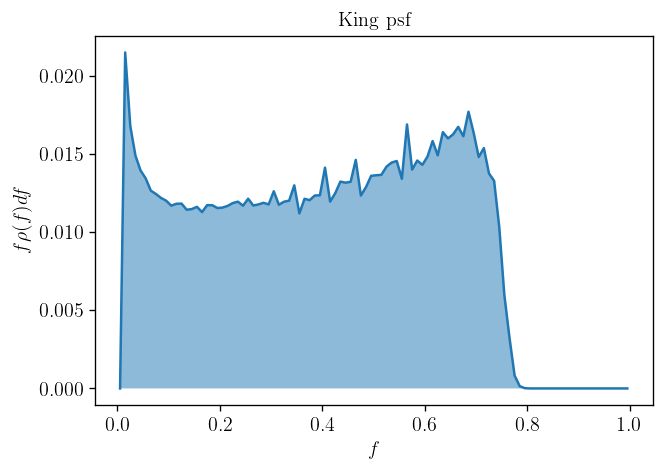

In [10]:
f_ary, df_rho_div_f_ary = get_psf_info(psf='king', num_f_bins=100)
plot_psf(f_ary, df_rho_div_f_ary, 'King psf');

In [9]:
temp_ps = {'dsk': np.ones(hp.nside2npix(nside))}

# S over A
Sps_over_A_dict = {}
for k in ['dsk']:
    s_ary = np.logspace(-1., 2., 100)
    vd = truth_dict
    theta_tmp = np.array([1., vd['n1_'+k], vd['n2_'+k], vd['n3_'+k], vd['sb1_'+k], vd['lambdas_'+k] * vd['sb1_'+k]])
    dnds_ary = dnds(s_ary, theta_tmp)
    Sps_over_A_dict[k] = np.mean(temp_ps[k][~mask_plane]) * np.trapz(s_ary * dnds_ary, s_ary)
print(Sps_over_A_dict)

{'dsk': 130.74215613068424}


In [33]:
ll_ss = []
counts_s = []
base_dir = 'iso'

pt_sum_compressed = np.full(np.sum(~mask_plane), 0., dtype=np.float64)
npt_compressed = np.array([temp_ps['dsk'][~mask_plane]])

for i_counts in tqdm(range(100)):
    counts = np.array(np.load(f"{base_dir}/counts_{i_counts}.npy"), dtype=np.int32)
    data_in = np.zeros(hp.nside2npix(nside), dtype=np.int32)
    data_in[~mask_plane] = counts
    data_in = np.array(data_in, dtype=np.int32)
    # k_max = int(np.max(data_in))
    # npixROI = int(np.sum(~mask_plane))
    counts_s.append(np.sum(counts))
    vd = truth_dict.copy()

    k = 'Sps_dsk'

    v_s = np.linspace(1.1, 1.5, 100)
    ll_s = []
    for i, v in enumerate(v_s):
        Sps = v
        k = 'dsk'
        A = Sps / Sps_over_A_dict[k]
        theta = np.array([[A, vd['n1_'+k], vd['n2_'+k], vd['n3_'+k], vd['sb1_'+k], vd['sb1_'+k]*vd['lambdas_'+k]]], dtype=np.float64)
        ll = npll.log_like(pt_sum_compressed, theta, f_ary, df_rho_div_f_ary, npt_compressed, data_in[~mask_plane])
        ll_s.append(ll)
    ll_ss.append(ll_s)
pickle.dump(ll_ss, open(f"{base_dir}/nptfll_Spsdsk_nf100.p", 'wb'))

100%|██████████| 100/100 [17:11<00:00, 10.31s/it]


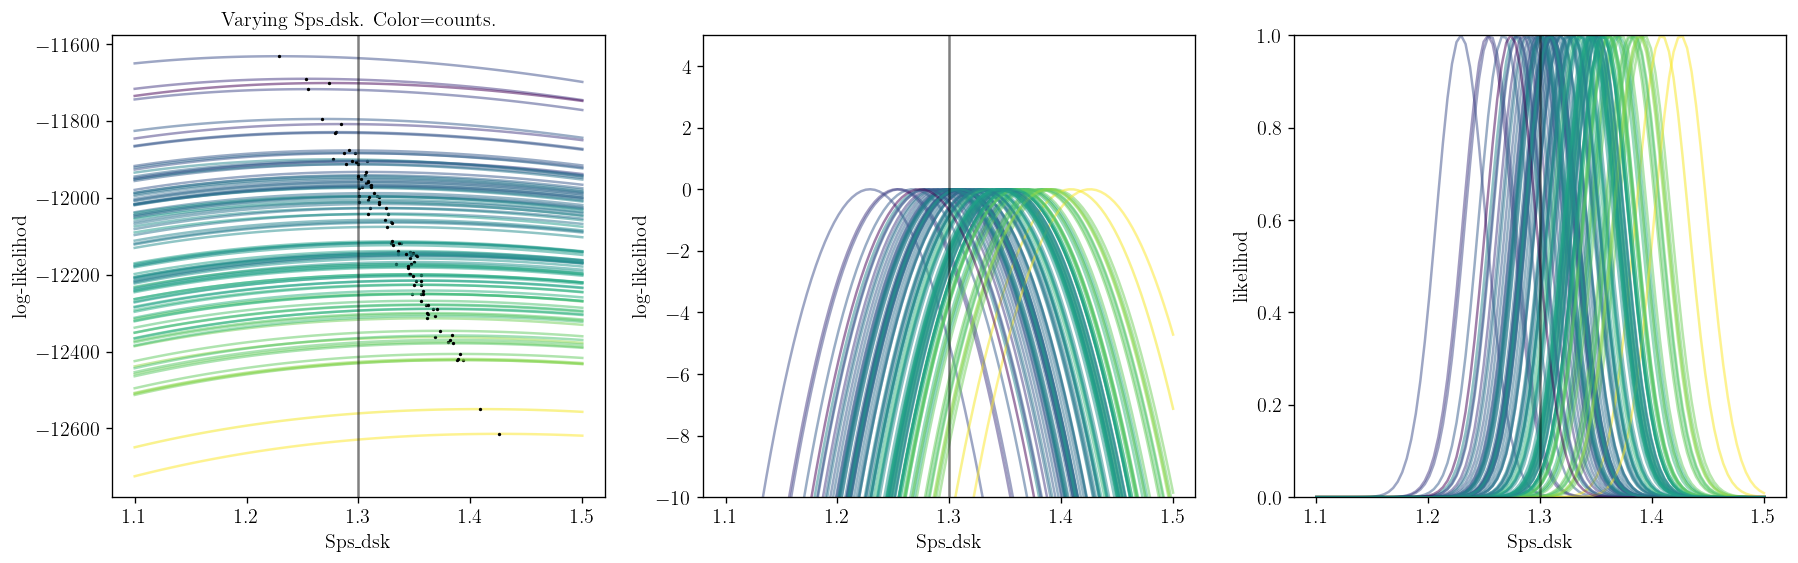

In [34]:
plot_1dll(ll_ss, v_s, truth_dict['Sps_dsk'], counts_s=counts_s, xlabel='Sps_dsk');

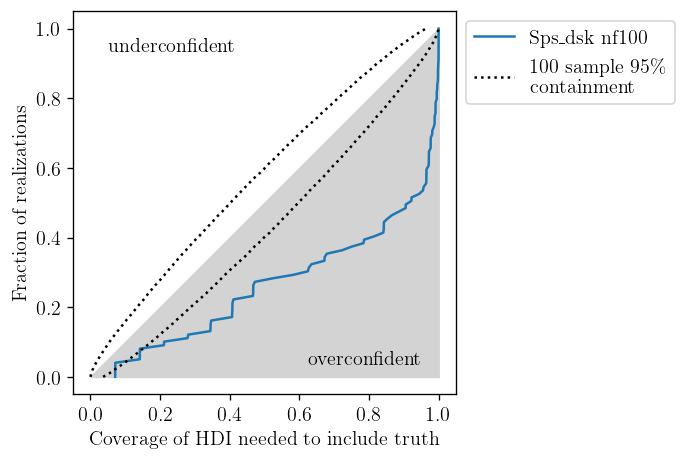

In [35]:
prob_samples = [
    find_pdf_hdi_prob(np.exp(ll_s-np.max(ll_s)), v_s, truth_dict['Sps_dsk'])
    for ll_s in ll_ss
]
plot_coverage([prob_samples], ['Sps_dsk nf100']);